In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

In [3]:
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

In [4]:
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

In [6]:
df = pd.read_csv("Country-data .csv")

In [7]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [8]:
df.shape

(167, 10)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    str    
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), str(1)
memory usage: 13.2 KB


In [10]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [11]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

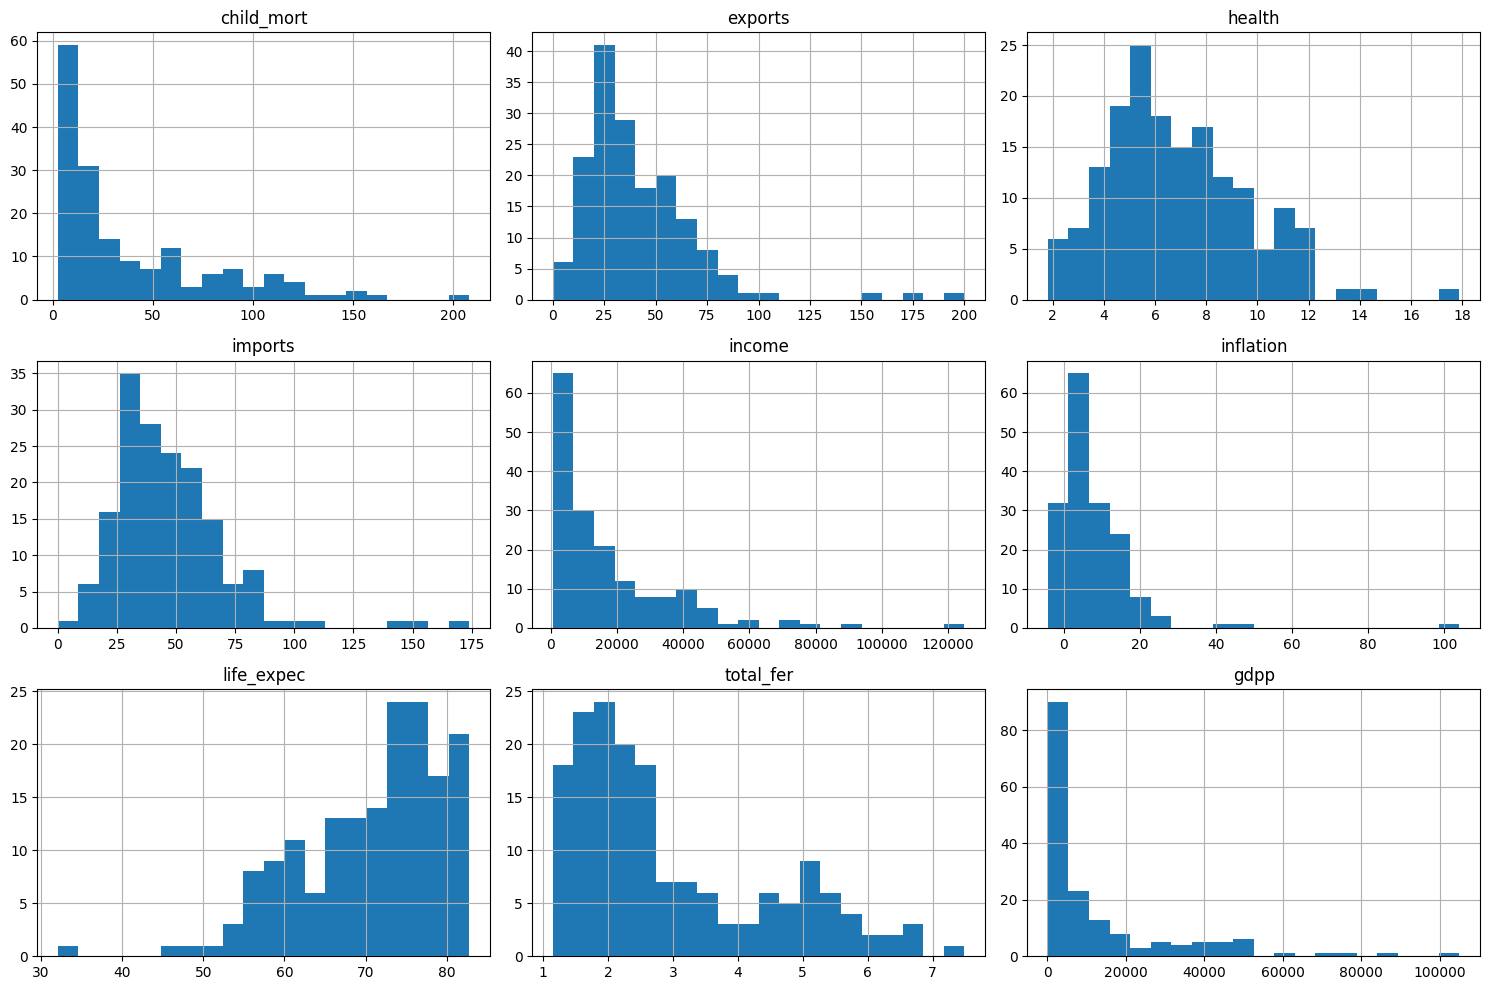

In [14]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

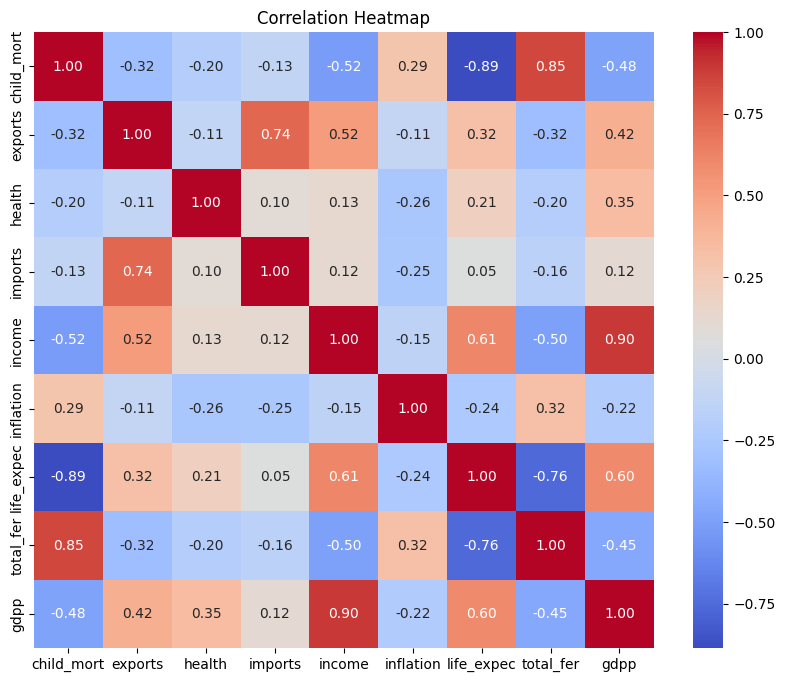

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(
    df.drop('country', axis=1).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

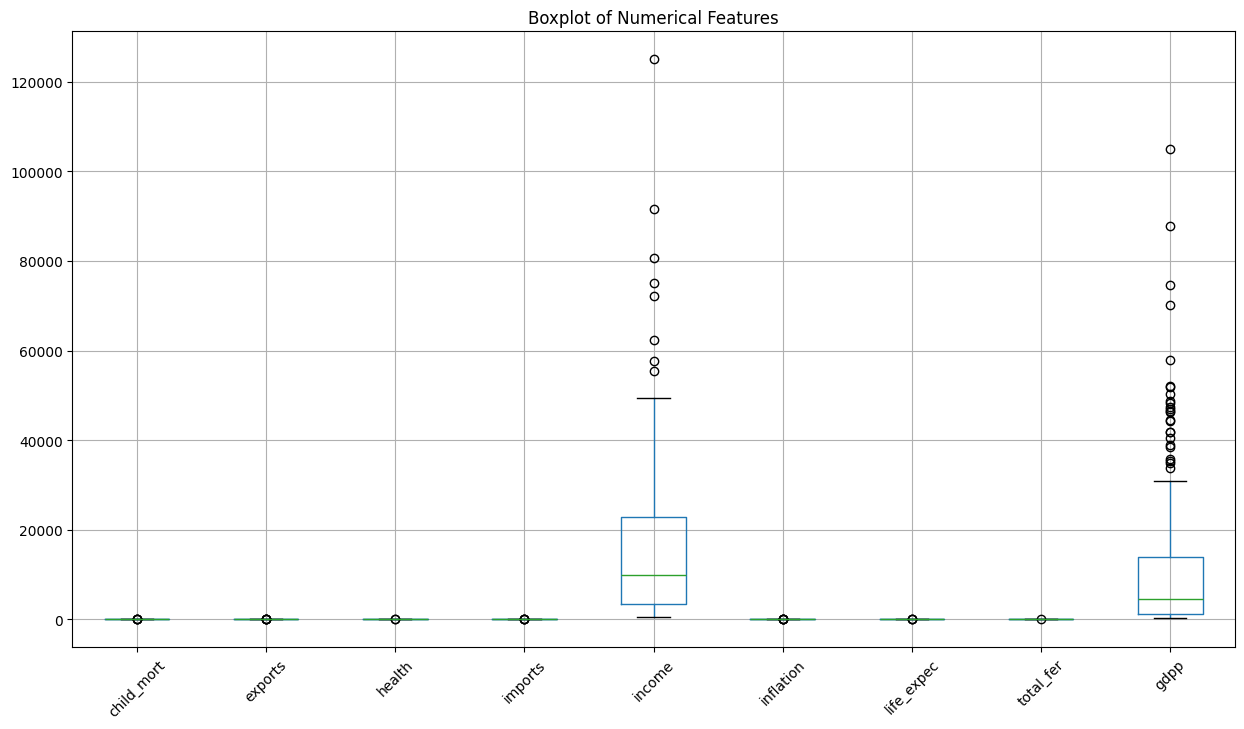

In [16]:
plt.figure(figsize=(15,8))
df.drop("country", axis=1).boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

In [17]:
X = df.drop("country", axis=1)
X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


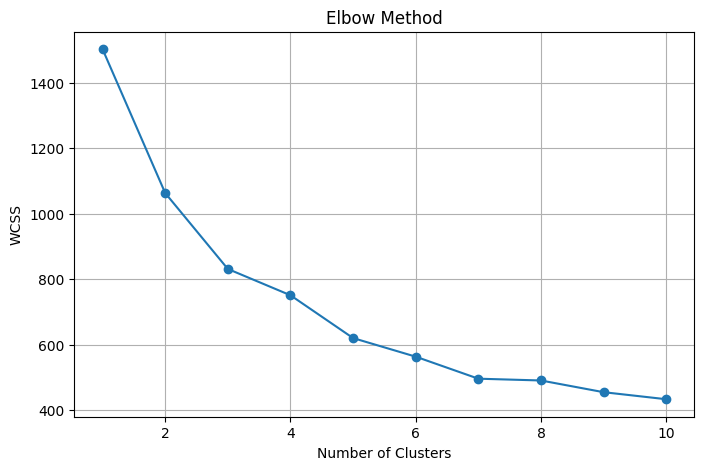

In [19]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


In [21]:
df["Cluster"].value_counts()

Cluster
0    86
2    45
1    36
Name: count, dtype: int64

In [22]:
df.groupby("Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


In [23]:
X = X_scaled
y = df["Cluster"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print("=" * 55)
    print(model_name)
    print("=" * 55)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    return accuracy, precision, recall, f1, y_pred

In [26]:
logistic = LogisticRegression(random_state=42)

log_accuracy, log_precision, log_recall, log_f1, log_prediction = evaluate_model(
    logistic,
    X_train,
    X_test,
    y_train,
    y_test,
    "Logistic Regression"
)

Logistic Regression
Accuracy : 0.9706
Precision: 0.9735
Recall   : 0.9706
F1 Score : 0.9709

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [27]:
naive_bayes = GaussianNB()

nb_accuracy, nb_precision, nb_recall, nb_f1, nb_prediction = evaluate_model(
    naive_bayes,
    X_train,
    X_test,
    y_train,
    y_test,
    "Naive Bayes"
)

Naive Bayes
Accuracy : 0.9118
Precision: 0.9338
Recall   : 0.9118
F1 Score : 0.9141

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       1.00      1.00      1.00         7
           2       0.75      1.00      0.86         9

    accuracy                           0.91        34
   macro avg       0.92      0.94      0.92        34
weighted avg       0.93      0.91      0.91        34



In [28]:
knn = KNeighborsClassifier(n_neighbors=5)

knn_accuracy, knn_precision, knn_recall, knn_f1, knn_prediction = evaluate_model(
    knn,
    X_train,
    X_test,
    y_train,
    y_test,
    "K-Nearest Neighbors"
)

K-Nearest Neighbors
Accuracy : 0.9706
Precision: 0.9735
Recall   : 0.9706
F1 Score : 0.9709

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [29]:
svm = SVC(random_state=42)

svm_accuracy, svm_precision, svm_recall, svm_f1, svm_prediction = evaluate_model(
    svm,
    X_train,
    X_test,
    y_train,
    y_test,
    "Support Vector Machine"
)

Support Vector Machine
Accuracy : 0.9412
Precision: 0.9519
Recall   : 0.9412
F1 Score : 0.9424

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        18
           1       1.00      1.00      1.00         7
           2       0.82      1.00      0.90         9

    accuracy                           0.94        34
   macro avg       0.94      0.96      0.95        34
weighted avg       0.95      0.94      0.94        34



In [30]:
decision_tree = DecisionTreeClassifier(random_state=42)

dt_accuracy, dt_precision, dt_recall, dt_f1, dt_prediction = evaluate_model(
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test,
    "Decision Tree"
)

Decision Tree
Accuracy : 0.9118
Precision: 0.9338
Recall   : 0.9118
F1 Score : 0.9141

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       1.00      1.00      1.00         7
           2       0.75      1.00      0.86         9

    accuracy                           0.91        34
   macro avg       0.92      0.94      0.92        34
weighted avg       0.93      0.91      0.91        34



In [31]:
classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "K-Nearest Neighbors",
        "Support Vector Machine",
        "Decision Tree"
    ],
    "Accuracy": [
        log_accuracy,
        nb_accuracy,
        knn_accuracy,
        svm_accuracy,
        dt_accuracy
    ],
    "Precision": [
        log_precision,
        nb_precision,
        knn_precision,
        svm_precision,
        dt_precision
    ],
    "Recall": [
        log_recall,
        nb_recall,
        knn_recall,
        svm_recall,
        dt_recall
    ],
    "F1 Score": [
        log_f1,
        nb_f1,
        knn_f1,
        svm_f1,
        dt_f1
    ]
})

classification_comparison = classification_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

classification_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.970588,0.973529,0.970588,0.970942
2,K-Nearest Neighbors,0.970588,0.973529,0.970588,0.970942
3,Support Vector Machine,0.941176,0.951872,0.941176,0.942388
1,Naive Bayes,0.911765,0.933824,0.911765,0.914057
4,Decision Tree,0.911765,0.933824,0.911765,0.914057


In [32]:
random_forest = RandomForestClassifier(
    random_state=42
)

rf_accuracy, rf_precision, rf_recall, rf_f1, rf_prediction = evaluate_model(
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test,
    "Random Forest"
)

Random Forest
Accuracy : 0.9706
Precision: 0.9735
Recall   : 0.9706
F1 Score : 0.9709

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [33]:
adaboost = AdaBoostClassifier(
    random_state=42
)

ada_accuracy, ada_precision, ada_recall, ada_f1, ada_prediction = evaluate_model(
    adaboost,
    X_train,
    X_test,
    y_train,
    y_test,
    "AdaBoost"
)

AdaBoost
Accuracy : 0.9412
Precision: 0.9519
Recall   : 0.9412
F1 Score : 0.9424

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        18
           1       1.00      1.00      1.00         7
           2       0.82      1.00      0.90         9

    accuracy                           0.94        34
   macro avg       0.94      0.96      0.95        34
weighted avg       0.95      0.94      0.94        34



In [34]:
gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

gb_accuracy, gb_precision, gb_recall, gb_f1, gb_prediction = evaluate_model(
    gradient_boosting,
    X_train,
    X_test,
    y_train,
    y_test,
    "Gradient Boosting"
)

Gradient Boosting
Accuracy : 0.9118
Precision: 0.9338
Recall   : 0.9118
F1 Score : 0.9141

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.83      0.91        18
           1       1.00      1.00      1.00         7
           2       0.75      1.00      0.86         9

    accuracy                           0.91        34
   macro avg       0.92      0.94      0.92        34
weighted avg       0.93      0.91      0.91        34



In [36]:
from xgboost import XGBClassifier

In [37]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

xgb_accuracy, xgb_precision, xgb_recall, xgb_f1, xgb_prediction = evaluate_model(
    xgb,
    X_train,
    X_test,
    y_train,
    y_test,
    "XGBoost"
)

XGBoost
Accuracy : 0.9706
Precision: 0.9735
Recall   : 0.9706
F1 Score : 0.9709

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [40]:
from lightgbm import LGBMClassifier

In [41]:
lgbm = LGBMClassifier(random_state=42)

lgbm_accuracy, lgbm_precision, lgbm_recall, lgbm_f1, lgbm_prediction = evaluate_model(
    lgbm,
    X_train,
    X_test,
    y_train,
    y_test,
    "LightGBM"
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 402
[LightGBM] [Info] Number of data points in the train set: 133, number of used features: 9
[LightGBM] [Info] Start training from score -0.670841
[LightGBM] [Info] Start training from score -1.523053
[LightGBM] [Info] Start training from score -1.306830
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [42]:
estimators = [
    ("rf", RandomForestClassifier(random_state=42)),
    ("knn", KNeighborsClassifier()),
    ("lr", LogisticRegression(random_state=42))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_accuracy, stack_precision, stack_recall, stack_f1, stack_prediction = evaluate_model(
    stacking,
    X_train,
    X_test,
    y_train,
    y_test,
    "Stacking Classifier"
)

Stacking Classifier
Accuracy : 0.9706
Precision: 0.9735
Recall   : 0.9706
F1 Score : 0.9709

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [43]:
estimators = [
    ("rf", RandomForestClassifier(random_state=42)),
    ("knn", KNeighborsClassifier()),
    ("lr", LogisticRegression(random_state=42))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_accuracy, stack_precision, stack_recall, stack_f1, stack_prediction = evaluate_model(
    stacking,
    X_train,
    X_test,
    y_train,
    y_test,
    "Stacking Classifier"
)

Stacking Classifier
Accuracy : 0.9706
Precision: 0.9735
Recall   : 0.9706
F1 Score : 0.9709

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        18
           1       1.00      1.00      1.00         7
           2       0.90      1.00      0.95         9

    accuracy                           0.97        34
   macro avg       0.97      0.98      0.97        34
weighted avg       0.97      0.97      0.97        34



In [44]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "K-Nearest Neighbors",
        "Support Vector Machine",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "Stacking Classifier"
    ],

    "Accuracy": [
        log_accuracy,
        nb_accuracy,
        knn_accuracy,
        svm_accuracy,
        dt_accuracy,
        rf_accuracy,
        ada_accuracy,
        gb_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        stack_accuracy
    ],

    "Precision": [
        log_precision,
        nb_precision,
        knn_precision,
        svm_precision,
        dt_precision,
        rf_precision,
        ada_precision,
        gb_precision,
        xgb_precision,
        lgbm_precision,
        stack_precision
    ],

    "Recall": [
        log_recall,
        nb_recall,
        knn_recall,
        svm_recall,
        dt_recall,
        rf_recall,
        ada_recall,
        gb_recall,
        xgb_recall,
        lgbm_recall,
        stack_recall
    ],

    "F1 Score": [
        log_f1,
        nb_f1,
        knn_f1,
        svm_f1,
        dt_f1,
        rf_f1,
        ada_f1,
        gb_f1,
        xgb_f1,
        lgbm_f1,
        stack_f1
    ]
})

final_comparison = final_comparison.sort_values(
    by="Accuracy",
    ascending=False
)

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.970588,0.973529,0.970588,0.970942
2,K-Nearest Neighbors,0.970588,0.973529,0.970588,0.970942
5,Random Forest,0.970588,0.973529,0.970588,0.970942
10,Stacking Classifier,0.970588,0.973529,0.970588,0.970942
8,XGBoost,0.970588,0.973529,0.970588,0.970942
9,LightGBM,0.941176,0.951872,0.941176,0.942388
3,Support Vector Machine,0.941176,0.951872,0.941176,0.942388
6,AdaBoost,0.941176,0.951872,0.941176,0.942388
1,Naive Bayes,0.911765,0.933824,0.911765,0.914057
4,Decision Tree,0.911765,0.933824,0.911765,0.914057


In [45]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,child_mort,0.296120
8,gdpp,0.227301
4,income,0.164629
6,life_expec,0.164469
7,total_fer,0.097647
2,health,0.017380
1,exports,0.011820
5,inflation,0.011761
3,imports,0.008873


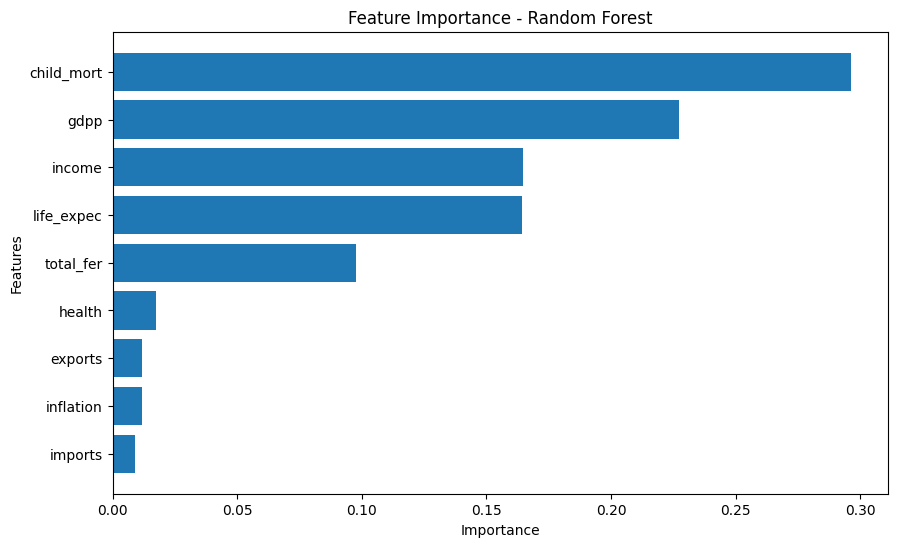

In [46]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

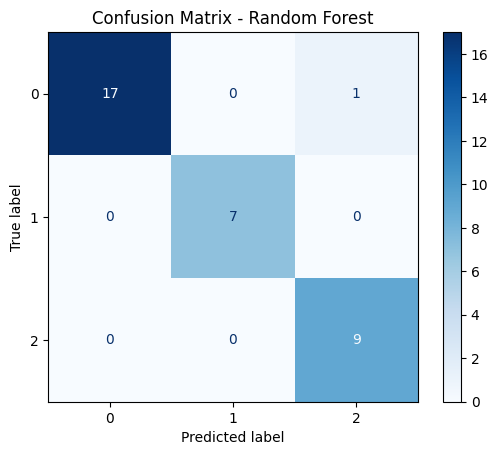

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    random_forest,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

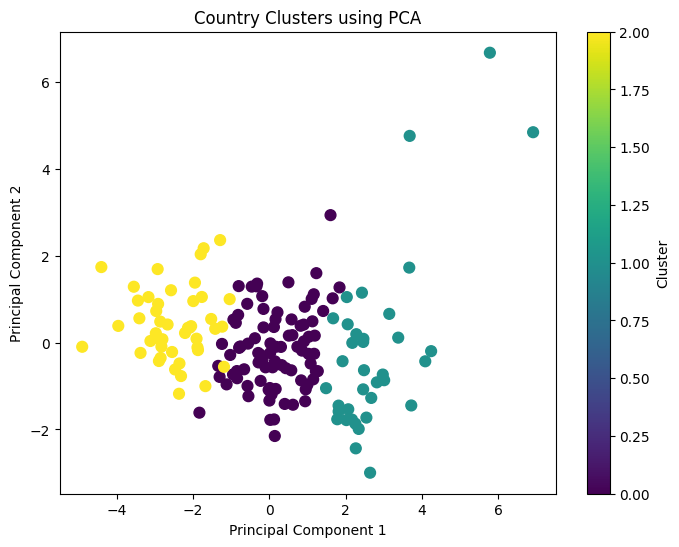

In [48]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Country Clusters using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [54]:
from sklearn.cluster import DBSCAN

In [55]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0


In [56]:
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64

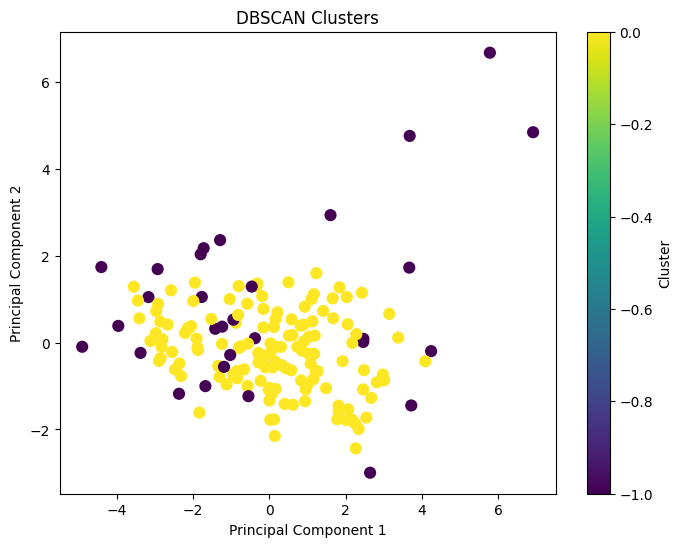

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["DBSCAN_Cluster"],
    cmap="viridis",
    s=60
)

plt.title("DBSCAN Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [58]:
from sklearn.cluster import AgglomerativeClustering

In [59]:
hierarchical = AgglomerativeClustering(
    n_clusters=3
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

df["Hierarchical_Cluster"] = hierarchical_labels

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster,Hierarchical_Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,0,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,0,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,-1,1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0,0,1


In [60]:
df["Hierarchical_Cluster"].value_counts()

Hierarchical_Cluster
1    106
0     34
2     27
Name: count, dtype: int64

In [61]:
df.groupby("Hierarchical_Cluster").mean(numeric_only=True)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster,DBSCAN_Cluster
Hierarchical_Cluster,,,,,,,,,,,
0,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235,0.911765,-0.264706
1,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925,0.386792,-0.150943
2,105.070370,23.589630,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889,2.000000,-0.185185


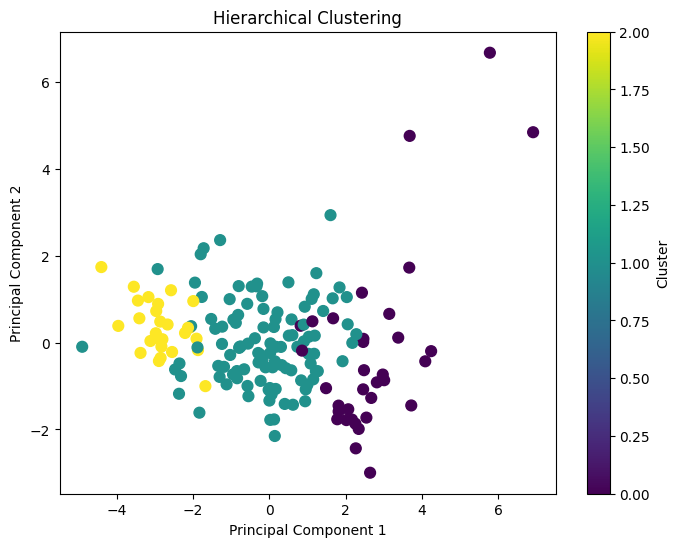

In [62]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["Hierarchical_Cluster"],
    cmap="viridis",
    s=60
)

plt.title("Hierarchical Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

<Figure size 600x500 with 0 Axes>

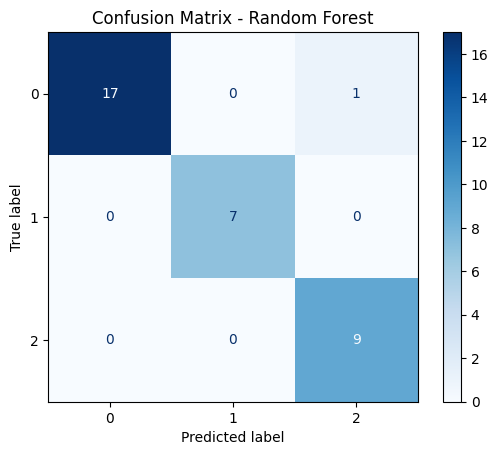

In [63]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=random_forest.classes_
)

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

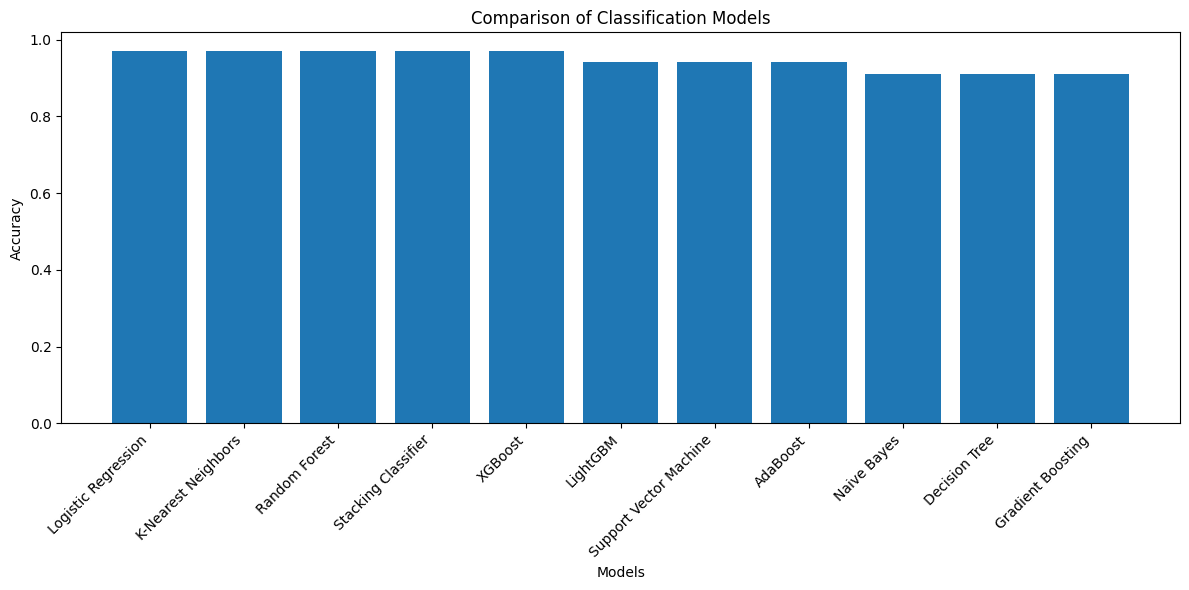

In [64]:
plt.figure(figsize=(12,6))

plt.bar(
    final_comparison["Model"],
    final_comparison["Accuracy"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.title("Comparison of Classification Models")

plt.tight_layout()
plt.show()